# EDA Sample:

In [ ]:
import pandas as pd

df = pd.read_parquet("merged_sample_one_processed/final_stage/part.0.parquet")
print(f"Shape: {df.shape}")

Shape: (1213641, 61)


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1213641 entries, 0 to 1213640
Data columns (total 61 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   anon_id                  1213641 non-null  string 
 1   pat_enc_csn_id_coded     1213641 non-null  int64  
 2   order_proc_id_coded      1213641 non-null  int64  
 3   order_time_jittered_utc  1213641 non-null  string 
 4   organism                 1213641 non-null  int8   
 5   antibiotic               1213641 non-null  int8   
 6   susceptibility           1213641 non-null  Int8   
 7   med_within_30_days       0 non-null        boolean
 8   n_med_categories         0 non-null        float64
 9   min_time_to_med          0 non-null        Int32  
 10  age                      1213641 non-null  Int8   
 11  gender                   1213641 non-null  Int8   
 12  median_wbc               1142011 non-null  float32
 13  median_neutrophils       650250 non-null   float32
 1

In [ ]:
print(df['susceptibility'].value_counts())

susceptibility
0    827853
1    385788
Name: count, dtype: Int64


0 => Susceptible
1 => Resistant


Susceptibility distribution saved to figs/susceptibility_distribution.png


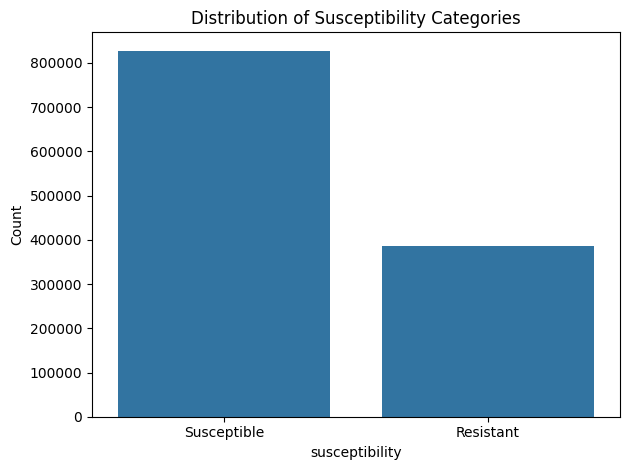

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = "figs"

sns.countplot(x='susceptibility', data=df)
plt.title("Distribution of Susceptibility Categories")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Susceptible", "Resistant"])  # Change tick labels only
plt.tight_layout()
plt.savefig(f"{fig_dir}/susceptibility_distribution.png")
print(f"Susceptibility distribution saved to {fig_dir}/susceptibility_distribution.png")
plt.show()

## Correlation Heatmap

In [ ]:
# Explicitly drop key columns
cols_to_drop = [
    "anon_id",
    "pat_enc_csn_id_coded",
    "order_proc_id_coded",
    "order_time_jittered_utc"
]

X_numeric = df.drop(columns=cols_to_drop, errors="ignore")

Correlation heatmap saved to figs/correlation_heatmap.png


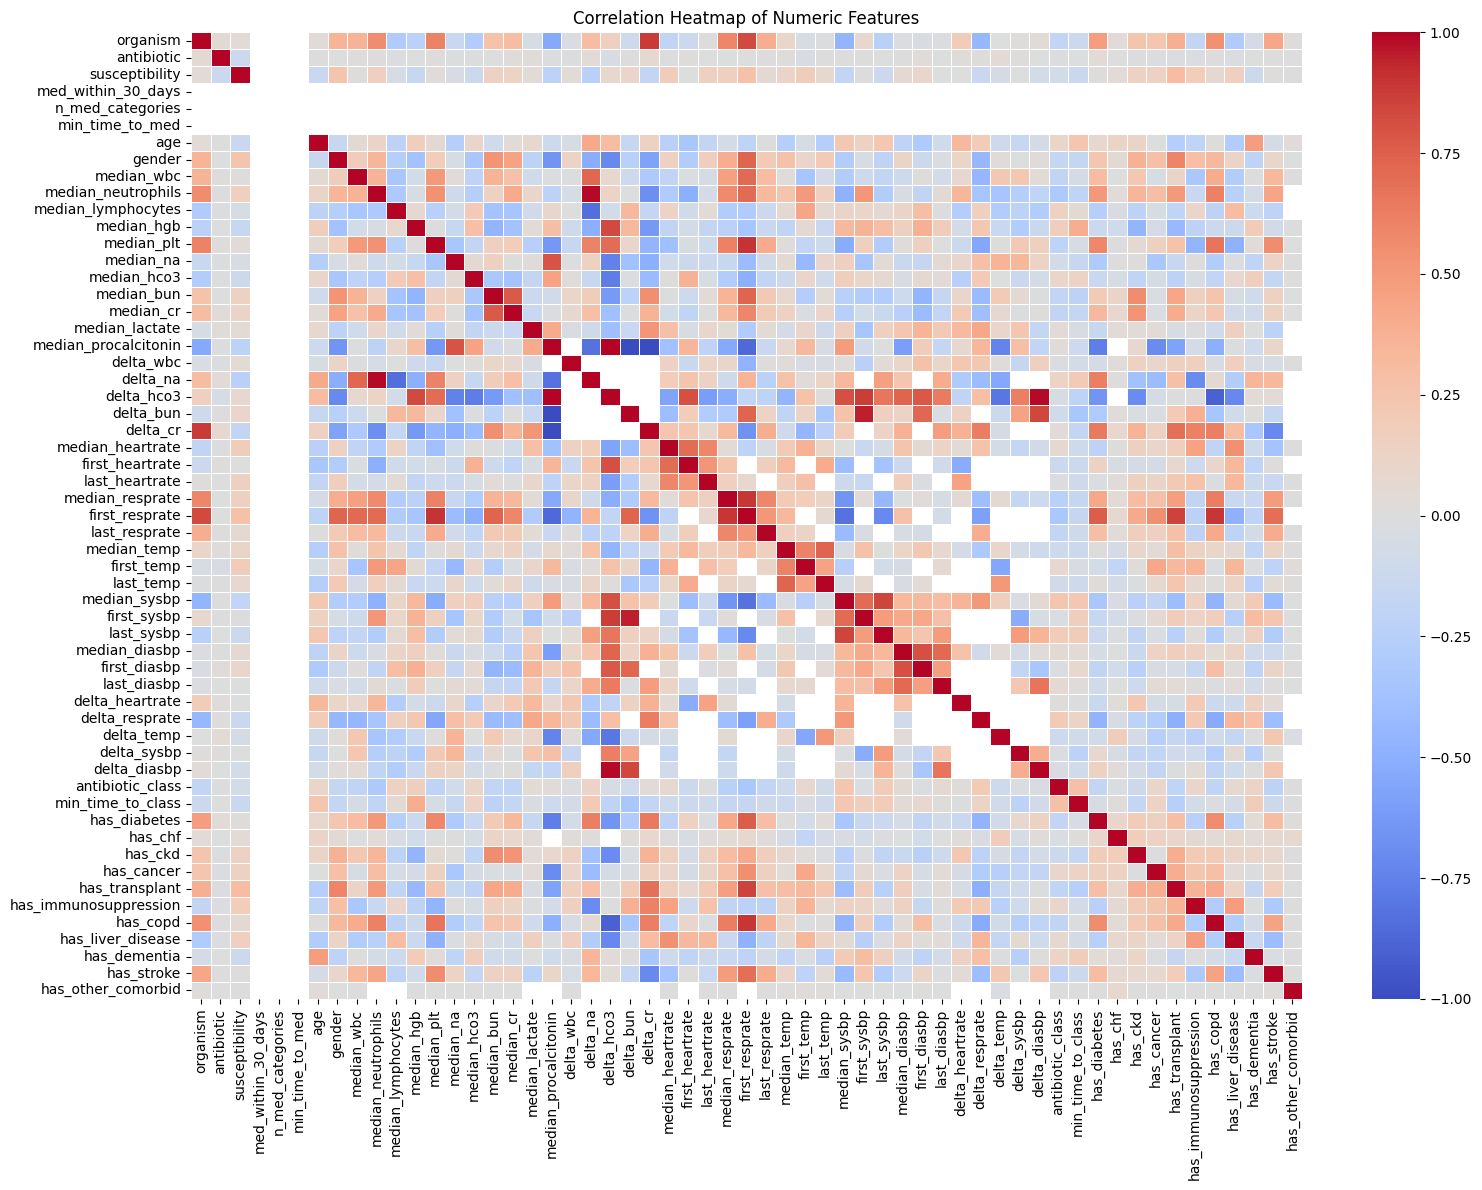

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = "figs"

df_corr = X_numeric.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(df_corr, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig(f"{fig_dir}/correlation_heatmap.png", dpi=300)
print(f"Correlation heatmap saved to {fig_dir}/correlation_heatmap.png")
plt.show()
